# 5 — Benchmark U-Net ConvNeXt Tiny

|                |                                           |
| -------------- | ----------------------------------------- |
| **Modèle**     | U-Net + encodeur ConvNeXt Tiny (ImageNet) |
| **Framework**  | TensorFlow / Keras                        |
| **Résolution** | 256 × 256                                 |
| **Loss**       | CE + 0.5 × Dice                           |
| **Métrique**   | mIoU (classes 0-7, IGNORE=255)            |

ConvNeXt (Liu et al., CVPR 2022) modernise le CNN classique avec des blocs inspirés des Vision Transformers :
déphasage des convolutions 7×7, LayerNorm, GELU, ratio channel plus large. Il représente ici la transition
entre CNN classiques (ResNet/VGG) et architectures full-transformer.

**Références** :

- Liu et al., _A ConvNet for the 2020s_, CVPR 2022 – https://arxiv.org/abs/2201.03545
- `tf.keras.applications.ConvNeXtTiny` (intégré dans TF ≥ 2.11)


In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")


ROOT = /home/ui/PROJ9


In [2]:
import os, gc, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras import backend as K

from scripts.config import ensure_dirs, resolve_split_csv, CITYSCAPES_DIR, EXP_DIR
from scripts.preprocessing import (
    load_rgb, load_mask_labelids, remap_to_groups, colorize_groups,
    CATEGORY_NAMES, IGNORE_LABEL, N_CLASSES, PALETTE
)
from scripts.datagen import CityscapesSequence
from scripts.augmentations import make_train_aug
from scripts.losses_metrics import MeanIoUArgmax, dice_loss_sparse
from scripts.models import unet_convnext_tiny, ConvNeXtPreprocess

ensure_dirs()
print("TF :", tf.__version__)
print("GPU :", [g.name for g in tf.config.list_physical_devices("GPU")])


2026-02-26 02:17:47.887651: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF : 2.20.0
GPU : ['/physical_device:GPU:0']


I0000 00:00:1772068672.919988 3931161 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9700 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:07:00.0, compute capability: 6.1


## Configuration :


In [3]:
# ── Hyperparamètres ────────────────────────────────────────────────
SIZE_HW           = (256, 256)
BATCH             = 4
EPOCHS            = 50
PATIENCE          = 10
AUG               = True
AUG_REPEATS       = 1
LOSS_NAME         = "ce_dice"
LR                = 1e-3
ENCODER_TRAINABLE = False   # Phase 1 : encodeur gelé

# Fine-tuning
EPOCHS_FT         = 30
LR_FT             = 1e-4
PATIENCE_FT       = 10
SEED              = 42

OUT_DIR = EXP_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"UNET_CONVNEXT_TINY_{SIZE_HW[0]}x{SIZE_HW[1]}"
    f"_b{BATCH}_aug{int(AUG)}_rep{AUG_REPEATS}_{LOSS_NAME}"
    f"_e{EPOCHS}ft{EPOCHS_FT}_seed{SEED}"
)
BEST_PATH    = OUT_DIR / f"{RUN_NAME}.keras"
RESULTS_JSON = OUT_DIR / f"{RUN_NAME}_results.json"
print("Run :", RUN_NAME)


Run : UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42


## Chargement des données :


In [4]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

df       = pd.read_csv(resolve_split_csv())
train_df = df[df["split_final"] == "train"].copy()
val_df   = df[df["split_final"] == "val"].copy()
test_df  = df[df["split_final"] == "test"].copy()
print(f"Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")

train_aug = make_train_aug() if AUG else None
train_seq = CityscapesSequence(train_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH,
    size_hw=SIZE_HW, augment=train_aug, shuffle=True, seed=SEED, aug_repeats=AUG_REPEATS)
val_seq   = CityscapesSequence(val_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH,
    size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED)
test_seq  = CityscapesSequence(test_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH,
    size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED)
print(f"Étapes — train: {len(train_seq)} | val: {len(val_seq)} | test: {len(test_seq)}")


Train : 2380  |  Val : 500  |  Test : 595
Étapes — train: 595 | val: 125 | test: 149


/home/ui/PROJ9/scripts/augmentations.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/home/ui/PROJ9/.env0/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Modèle U-Net ConvNeXt Tiny :


In [5]:
K.clear_session(); gc.collect()
model = unet_convnext_tiny(
    input_shape=(SIZE_HW[0], SIZE_HW[1], 3),
    n_classes=N_CLASSES,
    encoder_weights="imagenet",
    trainable=ENCODER_TRAINABLE,
)
model.summary(line_length=100)


Model: "unet_convnext_tiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_rgb_01 (InputLayer)   │ (None, 256, 256, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ convnext_preprocess         │ (None, 256, 256, 3)     │              0 │ image_rgb_01[0][0]      │
│ (ConvNeXtPreprocess)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ convnext_feat (Functional)  │ [(None, 64, 64, 96),    │     27,820,128 │ convnext_preprocess[0]… │
│                             │ (None, 32, 32, 192),    │                │                         │
│                             │ (None, 16, 16, 384),    │                │                         │
│                             │ (None, 8, 8, 768)]      │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ up_sampling2d               │ (None, 16, 16, 768)     │              0 │ convnext_feat[0][3]     │
│ (UpSampling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ concatenate (Concatenate)   │ (None, 16, 16, 1152)    │              0 │ up_sampling2d[0][0],    │
│                             │                         │                │ convnext_feat[0][2]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d (Conv2D)             │ (None, 16, 16, 512)     │      5,308,416 │ concatenate[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization         │ (None, 16, 16, 512)     │          2,048 │ conv2d[0][0]            │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ re_lu (ReLU)                │ (None, 16, 16, 512)     │              0 │ batch_normalization[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_1 (Conv2D)           │ (None, 16, 16, 512)     │      2,359,296 │ re_lu[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_1       │ (None, 16, 16, 512)     │          2,048 │ conv2d_1[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ re_lu_1 (ReLU)              │ (None, 16, 16, 512)     │              0 │ batch_normalization_1[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ up_sampling2d_1             │ (None, 32, 32, 512)     │              0 │ re_lu_1[0][0]           │
│ (UpSampling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ concatenate_1 (Concatenate) │ (None, 32, 32, 704)     │              0 │ up_sampling2d_1[0][0],  │
│                             │                         │                │ convnext_feat[0][1]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_2 (Conv2D)           │ (None, 32, 32, 256)     │    

 Total params: 38,371,432 (146.38 MB)

 Trainable params: 10,547,464 (40.24 MB)

 Non-trainable params: 27,823,968 (106.14 MB)

In [6]:
def compile_model(m, lr):
    def loss_fn(y_true, y_pred):
        y_t  = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
        valid = tf.not_equal(y_t, IGNORE_LABEL)
        y_s  = tf.where(valid, y_t, tf.zeros_like(y_t))
        ce   = tf.keras.losses.sparse_categorical_crossentropy(y_s, y_pred)
        ce   = tf.where(valid, ce, 0.0)
        denom = tf.reduce_sum(tf.cast(valid, tf.float32)) + 1e-6
        return tf.reduce_sum(ce) / denom + 0.5 * dice_loss_sparse(y_true, y_pred, n_classes=N_CLASSES)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[MeanIoUArgmax(num_classes=N_CLASSES, name="mIoU")],
    )
    return m


## Phase 1 — Entraînement avecl'encodeur gelé :


In [7]:
model = compile_model(model, lr=LR)

cb1 = [
    callbacks.ModelCheckpoint(str(BEST_PATH), monitor="val_mIoU", mode="max",
                               save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=4,
                                 factor=0.5, min_lr=1e-5, verbose=1),
    callbacks.CSVLogger(str(OUT_DIR / f"{RUN_NAME}_phase1.csv")),
]
t0    = time.time()
hist1 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS, callbacks=cb1, verbose=1)
t_ph1 = time.time() - t0
print(f"\nPhase 1 : {t_ph1/60:.1f} min")


Epoch 1/50


2026-02-26 02:18:05.575428: I external/local_xla/xla/service/service.cc:163] XLA service 0x718c2000fde0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-26 02:18:05.575991: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
2026-02-26 02:18:05.909941: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-26 02:18:08.902611: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-02-26 02:18:09.808644: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-26 02:18:16.761655: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[4,128,64,64]{3,2,1,0}, 

595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - loss: 0.9370 - mIoU: 0.4633

2026-02-26 02:22:54.369285: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_mIoU improved from None to 0.65642, saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 339s 393ms/step - loss: 0.7537 - mIoU: 0.5324 - val_loss: 0.5222 - val_mIoU: 0.6564 - learning_rate: 0.0010
Epoch 2/50
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 0.6075 - mIoU: 0.6110
Epoch 2: val_mIoU improved from 0.65642 to 0.68771, saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 230s 387ms/step - loss: 0.5865 - mIoU: 0.6211 - val_loss: 0.4657 - val_mIoU: 0.6877 - learning_rate: 0.0010
Epoch 3/50
595/595 ━━━━━━━━━━━━━━━━━━━

## Phase 2 — Fine-tuning (avec encodeur dégelé)


In [8]:
custom_objs = {"MeanIoUArgmax": MeanIoUArgmax, "dice_loss_sparse": dice_loss_sparse,
               "ConvNeXtPreprocess": ConvNeXtPreprocess}
model = tf.keras.models.load_model(str(BEST_PATH), custom_objects=custom_objs, compile=False)

# Dégèle l'encodeur ConvNeXt
for layer in model.layers:
    layer.trainable = True
model = compile_model(model, lr=LR_FT)

cb2 = [
    callbacks.ModelCheckpoint(str(BEST_PATH), monitor="val_mIoU", mode="max",
                               save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE_FT,
                             restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=4,
                                 factor=0.5, min_lr=1e-6, verbose=1),
    callbacks.CSVLogger(str(OUT_DIR / f"{RUN_NAME}_phase2.csv")),
]
t0    = time.time()
hist2 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS_FT, callbacks=cb2, verbose=1)
t_ph2 = time.time() - t0
t_tot = t_ph1 + t_ph2
print(f"\nPhase 2 : {t_ph2/60:.1f} min  |  Total : {t_tot/60:.1f} min")


Epoch 1/30


2026-02-26 05:12:26.305827: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 0.3026 - mIoU: 0.7727

2026-02-26 05:15:26.867507: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_mIoU improved from None to 0.75845, saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 235s 358ms/step - loss: 0.3079 - mIoU: 0.7693 - val_loss: 0.3605 - val_mIoU: 0.7584 - learning_rate: 1.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 0.3053 - mIoU: 0.7733
Epoch 2: val_mIoU improved from 0.75845 to 0.75923, saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 205s 344ms/step - loss: 0.3068 - mIoU: 0.7720 - val_loss: 0.3596 - val_mIoU: 0.7592 - learning_rate: 1.0000e-04
Epoch 3/30
595/595 ━━━━━━━━━━━

## Évaluation finale :


In [9]:
model = tf.keras.models.load_model(str(BEST_PATH), custom_objects=custom_objs, compile=False)
model = compile_model(model, lr=LR_FT)

val_res  = model.evaluate(val_seq,  verbose=1)
test_res = model.evaluate(test_seq, verbose=1)
print(f"\nVal  — Loss: {val_res[0]:.4f}  mIoU: {val_res[1]:.4f}")
print(f"Test — Loss: {test_res[0]:.4f}  mIoU: {test_res[1]:.4f}")


2026-02-26 06:54:37.792240: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 278ms/step - loss: 0.3614 - mIoU: 0.7598
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 0.3376 - mIoU: 0.7698

2026-02-26 06:56:02.644031: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-02-26 06:56:05.261586: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[3,128,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[3,352,64,64]{3,2,1,0}, f32[128,352,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-26 06:56:07.294069: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 3.032549814s
Trying algorithm eng3{k11=2} for conv (f32[3,128,64,64]{3,2,1,0}, u8[0]{0}) custom-cal

149/149 ━━━━━━━━━━━━━━━━━━━━ 55s 371ms/step - loss: 0.3227 - mIoU: 0.7759

Val  — Loss: 0.3614  mIoU: 0.7598
Test — Loss: 0.3227  mIoU: 0.7759


In [11]:
from sklearn.metrics import confusion_matrix

def compute_per_class_iou(model, seq, n_classes=N_CLASSES, ignore=IGNORE_LABEL):
    conf = np.zeros((n_classes, n_classes), dtype=np.int64)
    for X, y in seq:
        preds = np.argmax(model.predict(X, verbose=0), axis=-1)
        gt    = y[..., 0].astype(np.int32)
        valid = gt != ignore
        conf += confusion_matrix(gt[valid].flatten(), preds[valid].flatten(),
                                  labels=list(range(n_classes)))
    iou = []
    for c in range(n_classes):
        tp = conf[c,c]; fn = conf[c,:].sum()-tp; fp = conf[:,c].sum()-tp
        denom = tp+fn+fp
        iou.append(float(tp)/float(denom) if denom > 0 else 0.0)
    return iou

per_class_iou = compute_per_class_iou(model, test_seq)
miou_manual   = np.mean(per_class_iou)
print(f"mIoU test (manuel) = {miou_manual:.4f}\n")
for i, (name, v) in enumerate(zip(CATEGORY_NAMES, per_class_iou)):
    print(f"  {i} {name:<15} {v:.4f}  {'█'*int(v*30)}")


mIoU test (manuel) = 0.7759

  0 void            0.7970  ███████████████████████
  1 flat            0.9688  █████████████████████████████
  2 construction    0.8319  ████████████████████████
  3 object          0.3586  ██████████
  4 nature          0.8447  █████████████████████████
  5 sky             0.9129  ███████████████████████████
  6 human           0.6291  ██████████████████
  7 vehicle         0.8640  █████████████████████████


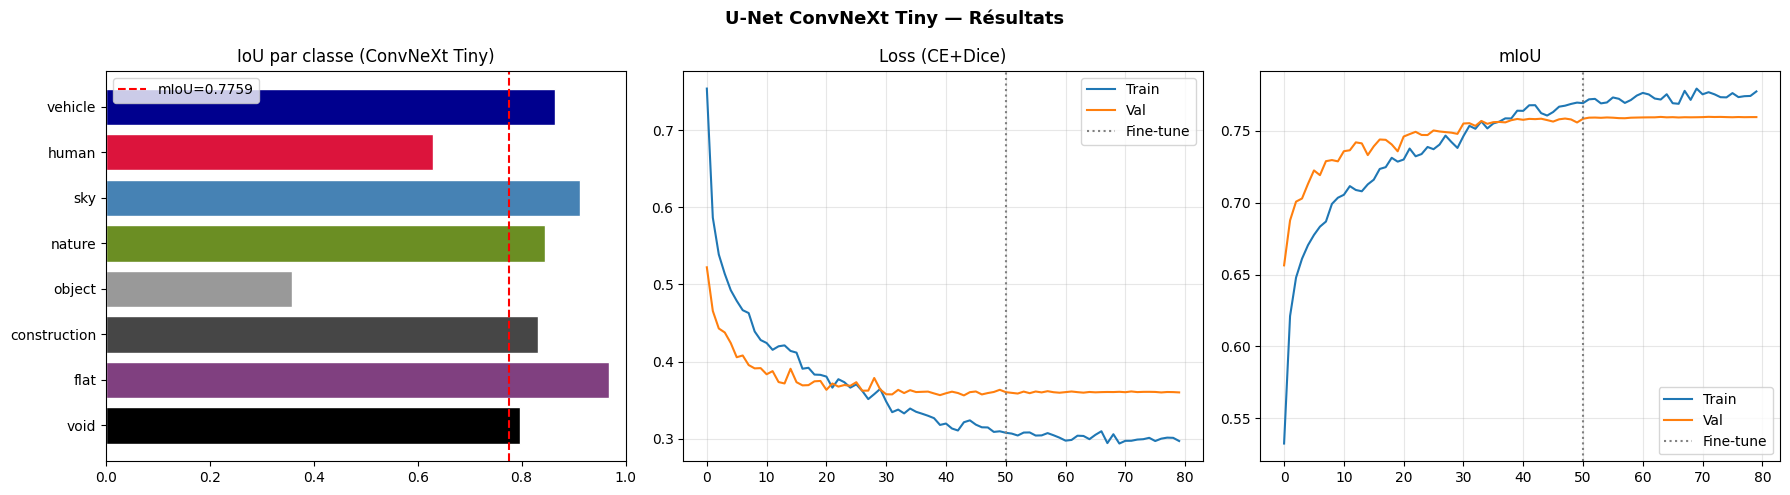

In [12]:
# — Figures : IoU par classe + courbes ─────────────────────────
all_loss  = hist1.history["loss"]  + hist2.history["loss"]
all_vloss = hist1.history["val_loss"] + hist2.history["val_loss"]
all_iou   = hist1.history["mIoU"]  + hist2.history["mIoU"]
all_viou  = hist1.history["val_mIoU"] + hist2.history["val_mIoU"]
ep_split  = len(hist1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = [tuple(c/255 for c in PALETTE[i]) for i in range(N_CLASSES)]

# IoU par classe
axes[0].barh(CATEGORY_NAMES, per_class_iou, color=colors, edgecolor="white")
axes[0].axvline(miou_manual, color="red", linestyle="--", label=f"mIoU={miou_manual:.4f}")
axes[0].set_xlim(0,1); axes[0].set_title("IoU par classe (ConvNeXt Tiny)"); axes[0].legend()

# Loss
axes[1].plot(all_loss, label="Train"); axes[1].plot(all_vloss, label="Val")
axes[1].axvline(ep_split, color="grey", linestyle=":", label="Fine-tune")
axes[1].set_title("Loss (CE+Dice)"); axes[1].legend(); axes[1].grid(alpha=0.3)

# mIoU
axes[2].plot(all_iou, label="Train"); axes[2].plot(all_viou, label="Val")
axes[2].axvline(ep_split, color="grey", linestyle=":", label="Fine-tune")
axes[2].set_title("mIoU"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("U-Net ConvNeXt Tiny — Résultats", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUT_DIR / f"{RUN_NAME}_summary.png"), dpi=120)
plt.show()


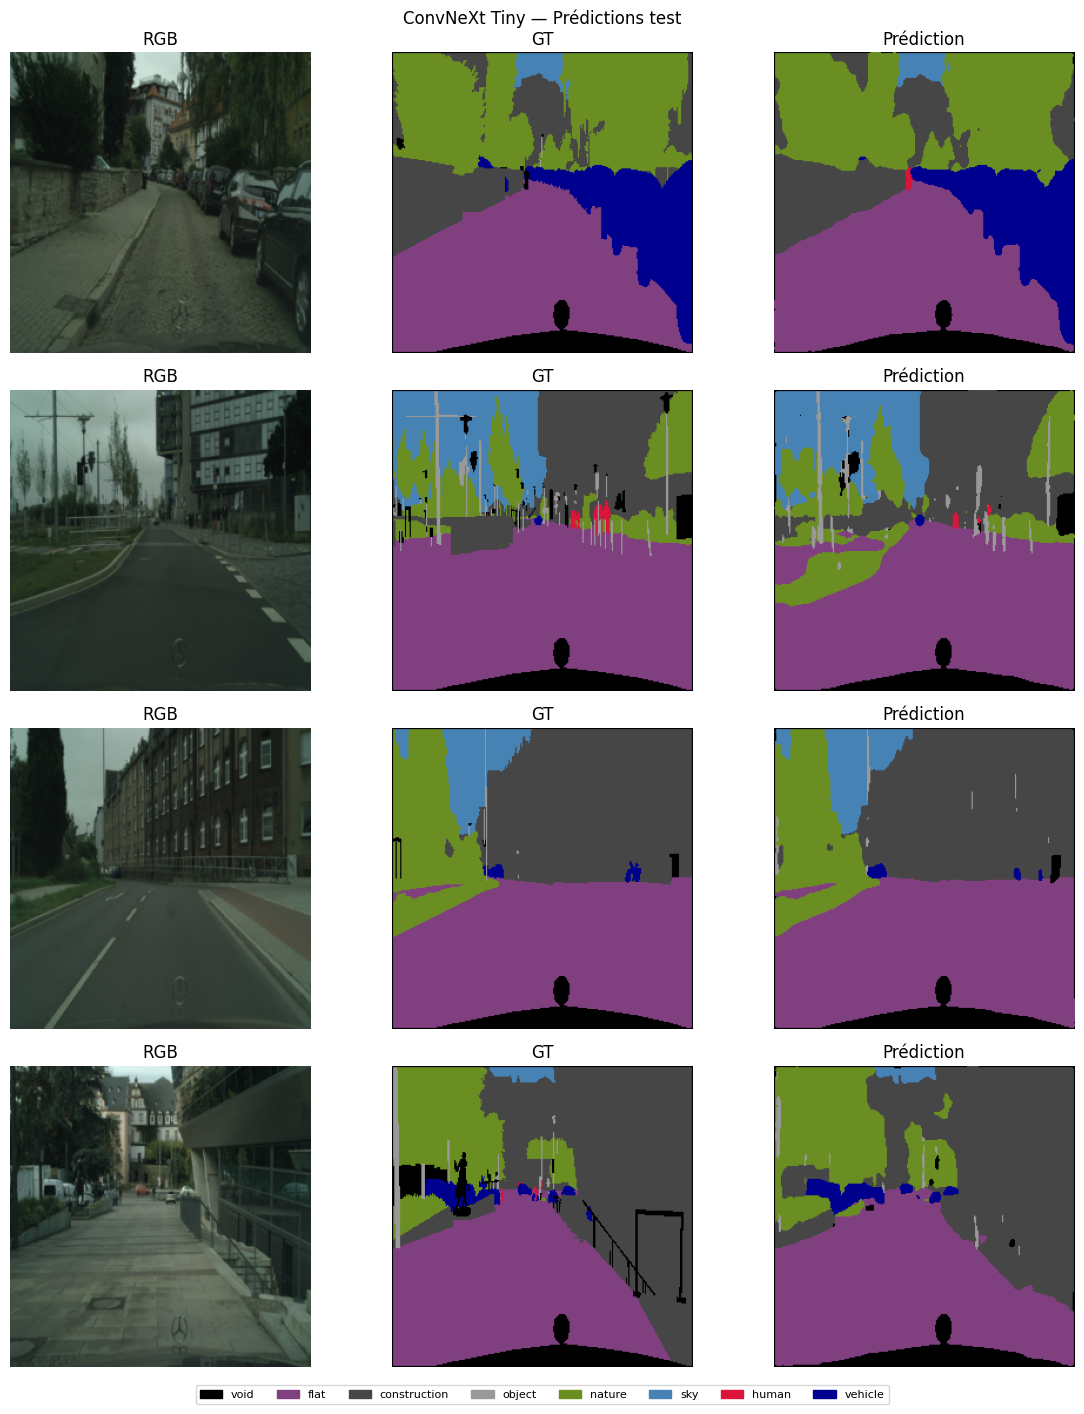

In [ ]:
from PIL import Image as PILImage

def show_predictions(model, seq, n=4):
    X, y   = seq[0]
    X, y   = X[:n], y[:n]
    preds  = np.argmax(model.predict(X, verbose=0), axis=-1)
    fig, axes = plt.subplots(n, 3, figsize=(12, n*3.5))
    for i in range(n):
        arr  = (X[i]*255).astype(np.uint8)
        gt_c = colorize_groups(PILImage.fromarray(y[i,...,0].astype(np.uint8)))
        pr_c = colorize_groups(PILImage.fromarray(preds[i].astype(np.uint8)))
        axes[i,0].imshow(arr);   axes[i,0].set_title("RGB")
        axes[i,1].imshow(gt_c);  axes[i,1].set_title("GT")
        axes[i,2].imshow(pr_c);  axes[i,2].set_title("Prédiction")
        for ax in axes[i]: ax.axis("off")
    patches = [mpatches.Patch(color=[c/255 for c in PALETTE[j]], label=CATEGORY_NAMES[j])
               for j in range(N_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=N_CLASSES,
               bbox_to_anchor=(0.5, -0.02), fontsize=8)
    plt.suptitle("ConvNeXt Tiny — Prédictions test")
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / f"{RUN_NAME}_preds.png"), dpi=100, bbox_inches="tight")
    plt.show()

show_predictions(model, test_seq)


## Sauvegarde JSON


In [14]:
combined_history = {
    key: hist1.history.get(key, []) + hist2.history.get(key, [])
    for key in ["loss", "val_loss", "mIoU", "val_mIoU"]
}

results = {
    "run_name"      : RUN_NAME,
    "model"         : "unet_convnext_tiny",
    "encoder"       : "convnext_tiny",
    "framework"     : "tensorflow",
    "input_shape"   : list(SIZE_HW) + [3],
    "best_path"     : str(BEST_PATH),
    "train_time_sec": float(t_tot),
    "epochs_phase1" : len(hist1.history["loss"]),
    "epochs_phase2" : len(hist2.history["loss"]),
    "val_loss"      : float(val_res[0]),
    "val_mIoU"      : float(val_res[1]),
    "test_loss"     : float(test_res[0]),
    "test_mIoU"     : float(test_res[1]),
    "per_class_iou" : {CATEGORY_NAMES[i]: round(per_class_iou[i], 4) for i in range(N_CLASSES)},
    "history"       : {k: [float(v) for v in vals] for k, vals in combined_history.items()},
}

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)

print(f"Résultats → {RESULTS_JSON}")
print(f"\n{'='*50}")
print(f" ConvNeXt Tiny — Résumé final")
print(f"{'='*50}")
print(f"  Val  mIoU : {results['val_mIoU']:.4f}")
print(f"  Test mIoU : {results['test_mIoU']:.4f}")
print(f"  Durée     : {t_tot/60:.1f} min")


Résultats → /home/ui/PROJ9/out/experiments/UNET_CONVNEXT_TINY_256x256_b4_aug1_rep1_ce_dice_e50ft30_seed42_results.json

 ConvNeXt Tiny — Résumé final
  Val  mIoU : 0.7598
  Test mIoU : 0.7759
  Durée     : 276.5 min
